# Feature Engineering: Phase 3

This notebook implements:
- 1. Credit risk split creation (out-of-sample and out-of-time)
- 10. Univariate distributions split by default / non-default
- 11. Correlation matrix and high-correlation flags (|r| > 0.7)
- 12. VIF-based multicollinearity filtering
- 13. Optimal binning with `optbinning`
- 14. WoE transformation
- 15. IV ranking and IV filtering
- 16. Final feature selection for logistic regression


In [1]:
from __future__ import annotations

import json
import warnings
import xml.etree.ElementTree as ET
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from optbinning import OptimalBinning
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_PATH = Path("data/cleaned_panel_imputed.csv")
DESCRIPTION_PATH = Path("data/description of variables 1.xlsx")
OUTPUT_DIR = Path("data")

TARGET_COL = "default"
ID_COL = "ID"
DATE_COL = "obs_date"

CORR_THRESHOLD = 0.7
VIF_THRESHOLD = 10.0
IV_MIN = 0.02
FINAL_FEATURES_MIN = 8
FINAL_FEATURES_MAX = 15
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Choose which prepared split to use for modeling in this notebook.
# Allowed values: "out_of_sample", "out_of_time".
MODELING_SPLIT_STRATEGY = "out_of_time"

NS = {"m": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}


def _load_shared_strings(workbook: zipfile.ZipFile) -> list[str]:
    root = ET.fromstring(workbook.read("xl/sharedStrings.xml"))
    shared: list[str] = []
    for si in root.findall("m:si", NS):
        text_parts = [text_node.text or "" for text_node in si.findall(".//m:t", NS)]
        shared.append("".join(text_parts))
    return shared


def _cell_value(cell: ET.Element, shared_strings: list[str]) -> str:
    cell_type = cell.attrib.get("t")
    if cell_type == "inlineStr":
        inline = cell.find("m:is/m:t", NS)
        return (inline.text or "") if inline is not None else ""

    value_node = cell.find("m:v", NS)
    if value_node is None:
        return ""

    value = value_node.text or ""
    if cell_type == "s":
        return shared_strings[int(value)]
    return value


def read_column_descriptions(xlsx_path: Path) -> dict[str, str]:
    with zipfile.ZipFile(xlsx_path) as workbook:
        shared_strings = _load_shared_strings(workbook)
        root = ET.fromstring(workbook.read("xl/worksheets/sheet2.xml"))

    rows = []
    for row in root.findall(".//m:sheetData/m:row", NS):
        row_values = []
        for cell in row.findall("m:c", NS):
            row_values.append(_cell_value(cell, shared_strings))
        rows.append(row_values)

    mapping: dict[str, str] = {}
    for row in rows[1:]:
        if len(row) >= 2 and row[0]:
            mapping[row[0].strip()] = row[1].strip()
    return mapping


## 1. Credit Risk Splits: Out-of-Sample and Out-of-Time

Create two leakage-safe `train/test` assignments for credit risk modeling:
- `out_of_sample`: company-level split by `ID` (80/20), stratified by company default flag
- `out_of_time`: last available year is `test`, earlier years are `train`

Also create one-row-per-company best-case snapshot for business scenario review.


In [2]:
# Create split files needed for credit risk modeling.
SPLIT_OOS_PATH = OUTPUT_DIR / "data_split_out_of_sample_train_test.csv"
SPLIT_OOT_PATH = OUTPUT_DIR / "data_split_out_of_time_last_year_train_test.csv"
BEST_CASE_PATH = OUTPUT_DIR / "company_best_case_once.csv"
SPLIT_SUMMARY_PATH = OUTPUT_DIR / "data_split_summary.csv"

split_df = pd.read_csv(DATA_PATH, sep=";", low_memory=False)
split_df[DATE_COL] = pd.to_datetime(split_df[DATE_COL], errors="coerce")
split_df[TARGET_COL] = pd.to_numeric(split_df[TARGET_COL], errors="coerce")
split_df = split_df.dropna(subset=[ID_COL, DATE_COL, TARGET_COL]).copy()
split_df[TARGET_COL] = split_df[TARGET_COL].astype(int)

if set(split_df[TARGET_COL].unique()) - {0, 1}:
    raise ValueError("Target must be binary encoded as 0/1.")


def stratified_company_train_test_ids(
    company_target: pd.Series,
    test_size: float = 0.2,
    seed: int = RANDOM_STATE,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    labels = company_target.astype(int)

    if labels.nunique() < 2:
        ids = np.array(labels.index.to_numpy(), copy=True)
        rng.shuffle(ids)
        n_test = int(np.floor(len(ids) * test_size))
        n_test = max(1, n_test)
        return ids[n_test:], ids[:n_test]

    train_parts: list[np.ndarray] = []
    test_parts: list[np.ndarray] = []

    for _, label_ids in labels.groupby(labels):
        ids = np.array(label_ids.index.to_numpy(), copy=True)
        rng.shuffle(ids)
        n_test = int(np.floor(len(ids) * test_size))
        n_test = max(1, n_test)
        n_test = min(n_test, len(ids) - 1)
        test_parts.append(ids[:n_test])
        train_parts.append(ids[n_test:])

    return np.concatenate(train_parts), np.concatenate(test_parts)


company_target = split_df.groupby(ID_COL)[TARGET_COL].max().astype(int)
train_ids, test_ids = stratified_company_train_test_ids(company_target, test_size=TEST_SIZE)

oos_split = split_df[[ID_COL, DATE_COL, TARGET_COL]].copy()
oos_split["split"] = np.where(oos_split[ID_COL].isin(set(train_ids.tolist())), "train", "test")
oos_split["split_type"] = "out_of_sample"

year_values = split_df[DATE_COL].dt.year
last_year = int(year_values.max())
oot_split = split_df[[ID_COL, DATE_COL, TARGET_COL]].copy()
oot_split["split"] = np.where(year_values == last_year, "test", "train")
oot_split["split_type"] = f"out_of_time_last_year_{last_year}"

numeric_cols = split_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_for_score = [c for c in numeric_cols if c not in {ID_COL, TARGET_COL}]
if not feature_cols_for_score:
    raise ValueError("No numeric feature columns found for best-case scoring.")

ranked = split_df[feature_cols_for_score].rank(method="average", pct=True)
oriented = ranked.copy()
for col in feature_cols_for_score:
    corr = ranked[col].corr(split_df[TARGET_COL])
    if pd.notna(corr) and corr > 0:
        oriented[col] = 1.0 - ranked[col]

health_score = oriented.mean(axis=1, skipna=True)
best_case = split_df[[ID_COL, DATE_COL, TARGET_COL]].copy()
best_case["health_score"] = health_score
best_case = best_case.sort_values(
    by=[ID_COL, TARGET_COL, "health_score", DATE_COL],
    ascending=[True, True, False, False],
)
best_case = best_case.drop_duplicates(subset=[ID_COL], keep="first").copy()
best_case["selection_rule"] = "prefer_non_default_then_highest_health_score_then_latest_date"


def split_summary_table(frame: pd.DataFrame) -> pd.DataFrame:
    tmp = frame.copy()
    tmp["year"] = tmp[DATE_COL].dt.year
    return (
        tmp.groupby(["split_type", "year", "split"], as_index=False)
        .agg(rows=(ID_COL, "size"), default_rate=(TARGET_COL, "mean"))
        .sort_values(["split_type", "year", "split"])
    )

split_summary = pd.concat(
    [split_summary_table(oos_split), split_summary_table(oot_split)],
    ignore_index=True,
)

oos_split.to_csv(SPLIT_OOS_PATH, sep=";", index=False, date_format="%Y-%m-%d")
oot_split.to_csv(SPLIT_OOT_PATH, sep=";", index=False, date_format="%Y-%m-%d")
best_case.to_csv(BEST_CASE_PATH, sep=";", index=False, date_format="%Y-%m-%d")
split_summary.to_csv(SPLIT_SUMMARY_PATH, sep=";", index=False)

print(f"Rows used for split creation: {len(split_df):,}")
print(f"Last year used for out-of-time test: {last_year}")
print("Out-of-sample split rows:")
print(oos_split["split"].value_counts().to_string())
print("Out-of-time split rows:")
print(oot_split["split"].value_counts().to_string())
print(f"Best-case rows (one per company): {len(best_case):,}")
print(f"Saved: {SPLIT_OOS_PATH}")
print(f"Saved: {SPLIT_OOT_PATH}")
print(f"Saved: {BEST_CASE_PATH}")
print(f"Saved: {SPLIT_SUMMARY_PATH}")


Rows used for split creation: 125,758
Last year used for out-of-time test: 2021
Out-of-sample split rows:
split
train    100634
test      25124
Out-of-time split rows:
split
train    119128
test       6630
Best-case rows (one per company): 46,069
Saved: data\data_split_out_of_sample_train_test.csv
Saved: data\data_split_out_of_time_last_year_train_test.csv
Saved: data\company_best_case_once.csv
Saved: data\data_split_summary.csv


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Run data_processing.ipynb first to create cleaned data."
    )

if not DESCRIPTION_PATH.exists():
    raise FileNotFoundError(
        f"{DESCRIPTION_PATH} not found. Expected variable dictionary file."
    )

descriptions = read_column_descriptions(DESCRIPTION_PATH)

df = pd.read_csv(DATA_PATH, sep=";", low_memory=False)

if DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found.")

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
model_df = df.dropna(subset=[TARGET_COL, ID_COL, DATE_COL]).copy()
model_df[TARGET_COL] = model_df[TARGET_COL].astype(int)

if set(model_df[TARGET_COL].unique()) - {0, 1}:
    raise ValueError("Target must be binary encoded as 0/1.")


def feature_display_name(feature: str) -> str:
    if feature in descriptions:
        return descriptions[feature]

    if feature.endswith("_missing_flag"):
        base = feature[: -len("_missing_flag")]
        base_name = descriptions.get(base, base)
        return f"{base_name} (missing flag)"

    return feature


exclude_cols = {TARGET_COL, ID_COL, DATE_COL}
numeric_cols = model_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_raw = [c for c in numeric_cols if c not in exclude_cols]

if not feature_cols_raw:
    raise ValueError("No numeric feature columns available for modeling.")

SPLIT_OOS_PATH = OUTPUT_DIR / "data_split_out_of_sample_train_test.csv"
SPLIT_OOT_PATH = OUTPUT_DIR / "data_split_out_of_time_last_year_train_test.csv"

if MODELING_SPLIT_STRATEGY == "out_of_sample":
    split_path = SPLIT_OOS_PATH
elif MODELING_SPLIT_STRATEGY == "out_of_time":
    split_path = SPLIT_OOT_PATH
else:
    raise ValueError("MODELING_SPLIT_STRATEGY must be 'out_of_sample' or 'out_of_time'.")

if not split_path.exists():
    raise FileNotFoundError(
        f"{split_path} not found. Run section 1 (credit risk splits) first."
    )

split_assignment = pd.read_csv(split_path, sep=";")
if "split" not in split_assignment.columns:
    raise KeyError(f"Split file missing 'split' column: {split_path}")

split_assignment[DATE_COL] = pd.to_datetime(split_assignment[DATE_COL], errors="coerce")
split_assignment = split_assignment[[ID_COL, DATE_COL, "split"]].dropna(subset=[ID_COL, DATE_COL, "split"])

if split_assignment.duplicated(subset=[ID_COL, DATE_COL]).any():
    raise ValueError(f"Duplicate keys in split file {split_path}; expected unique (ID, obs_date).")

split_values = set(split_assignment["split"].astype(str).unique())
if split_values - {"train", "test"}:
    raise ValueError(f"Unexpected split labels in {split_path}: {sorted(split_values)}")

model_df = model_df.merge(
    split_assignment,
    on=[ID_COL, DATE_COL],
    how="left",
    validate="one_to_one",
)

if model_df["split"].isna().any():
    missing_rows = int(model_df["split"].isna().sum())
    raise ValueError(
        f"{missing_rows} rows have no split assignment in {split_path}."
    )

train_idx = model_df.index[model_df["split"] == "train"].to_numpy()
test_idx = model_df.index[model_df["split"] == "test"].to_numpy()

if len(train_idx) == 0 or len(test_idx) == 0:
    raise ValueError("Split must contain both train and test rows.")

y = model_df[TARGET_COL].copy()

X_raw = model_df[feature_cols_raw].copy()
X_train_raw = X_raw.loc[train_idx].copy()
X_test_raw = X_raw.loc[test_idx].copy()

y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()

if y_train.nunique() < 2 or y_test.nunique() < 2:
    raise ValueError("Both train and test must contain both target classes (0/1).")


def preprocess_with_train_statistics(frame: pd.DataFrame, medians: pd.Series) -> pd.DataFrame:
    out = frame.replace([np.inf, -np.inf], np.nan).copy()
    out = out.fillna(medians)
    return out


train_medians = X_train_raw.replace([np.inf, -np.inf], np.nan).median(numeric_only=True)

X_train = preprocess_with_train_statistics(X_train_raw, train_medians)
X_test = preprocess_with_train_statistics(X_test_raw, train_medians)
X = preprocess_with_train_statistics(X_raw, train_medians)

# Drop constant features based on train only and apply to all splits.
constant_features = [c for c in X_train.columns if X_train[c].nunique(dropna=True) <= 1]
if constant_features:
    X_train = X_train.drop(columns=constant_features)
    X_test = X_test.drop(columns=constant_features)
    X = X.drop(columns=constant_features)

feature_cols = X_train.columns.tolist()

FEATURE_NAME_MAP = {c: feature_display_name(c) for c in model_df.columns}
split_strategy = f"external_{MODELING_SPLIT_STRATEGY}"

print(f"Rows used: {len(model_df):,}")
print(f"Split strategy: {split_strategy}")
print(f"Split file: {split_path.name}")
print(f"Candidate numeric features before filtering: {len(feature_cols_raw)}")
print(f"Constant features dropped (train-only decision): {len(constant_features)}")
print(f"Final feature count: {len(feature_cols)}")


Rows used: 125,758
Split strategy: external_out_of_time
Split file: data_split_out_of_time_last_year_train_test.csv
Candidate numeric features before filtering: 75
Constant features dropped (train-only decision): 0
Final feature count: 75


In [4]:
# Split integrity diagnostics.
print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

print(f"Train default rate: {y_train.mean() * 100:.4f}%")
print(f"Test default rate: {y_test.mean() * 100:.4f}%")

if ID_COL in model_df.columns:
    id_train = set(model_df.loc[X_train.index, ID_COL].dropna().astype(str))
    id_test = set(model_df.loc[X_test.index, ID_COL].dropna().astype(str))
    overlap = len(id_train & id_test)
    print(f"ID overlap train-test: {overlap}")
    if MODELING_SPLIT_STRATEGY == "out_of_sample" and overlap != 0:
        raise ValueError("Out-of-sample split should have zero ID overlap between train and test.")


Train rows: 119,128
Test rows: 6,630
Train default rate: 7.0764%
Test default rate: 4.8115%
ID overlap train-test: 6343


## 10. Univariate distributions split by default / non-default

,feature,feature_name,mean_non_default,mean_default,smd,abs_smd
44,Var_06_missing_flag,Depreciation And Impairment (missing flag),7.567436e-02,1.408066e-01,0.210795,0.210795
17,Var_18,IFRS_Assets Total,1.367486e+09,2.809683e+11,0.151482,0.151482
1,Var_02,Assets Total,1.367486e+09,2.809683e+11,0.151482,0.151482
10,Var_11,Equity And Liabilities Total,1.369077e+09,2.809445e+11,0.151468,0.151468
18,Var_19,IFRS_Equity And Liabilities Total,1.369077e+09,2.809445e+11,0.151468,0.151468
29,Var_30,Sales Excluding VAT,1.284056e+09,2.035118e+11,0.144547,0.144547
28,Var_29,Revenues,1.283745e+09,2.135293e+11,0.144075,0.144075
42,Var_04_missing_flag,Current Ratio (missing flag),1.026215e-02,0.000000e+00,-0.144003,0.144003
60,Var_25_missing_flag,Quick Ratio (missing flag),1.026215e-02,0.000000e+00,-0.144003,0.144003
16,Var_17,IFRS_Assets Non Current Total,8.863663e+08,2.325034e+11,0.133828,0.133828


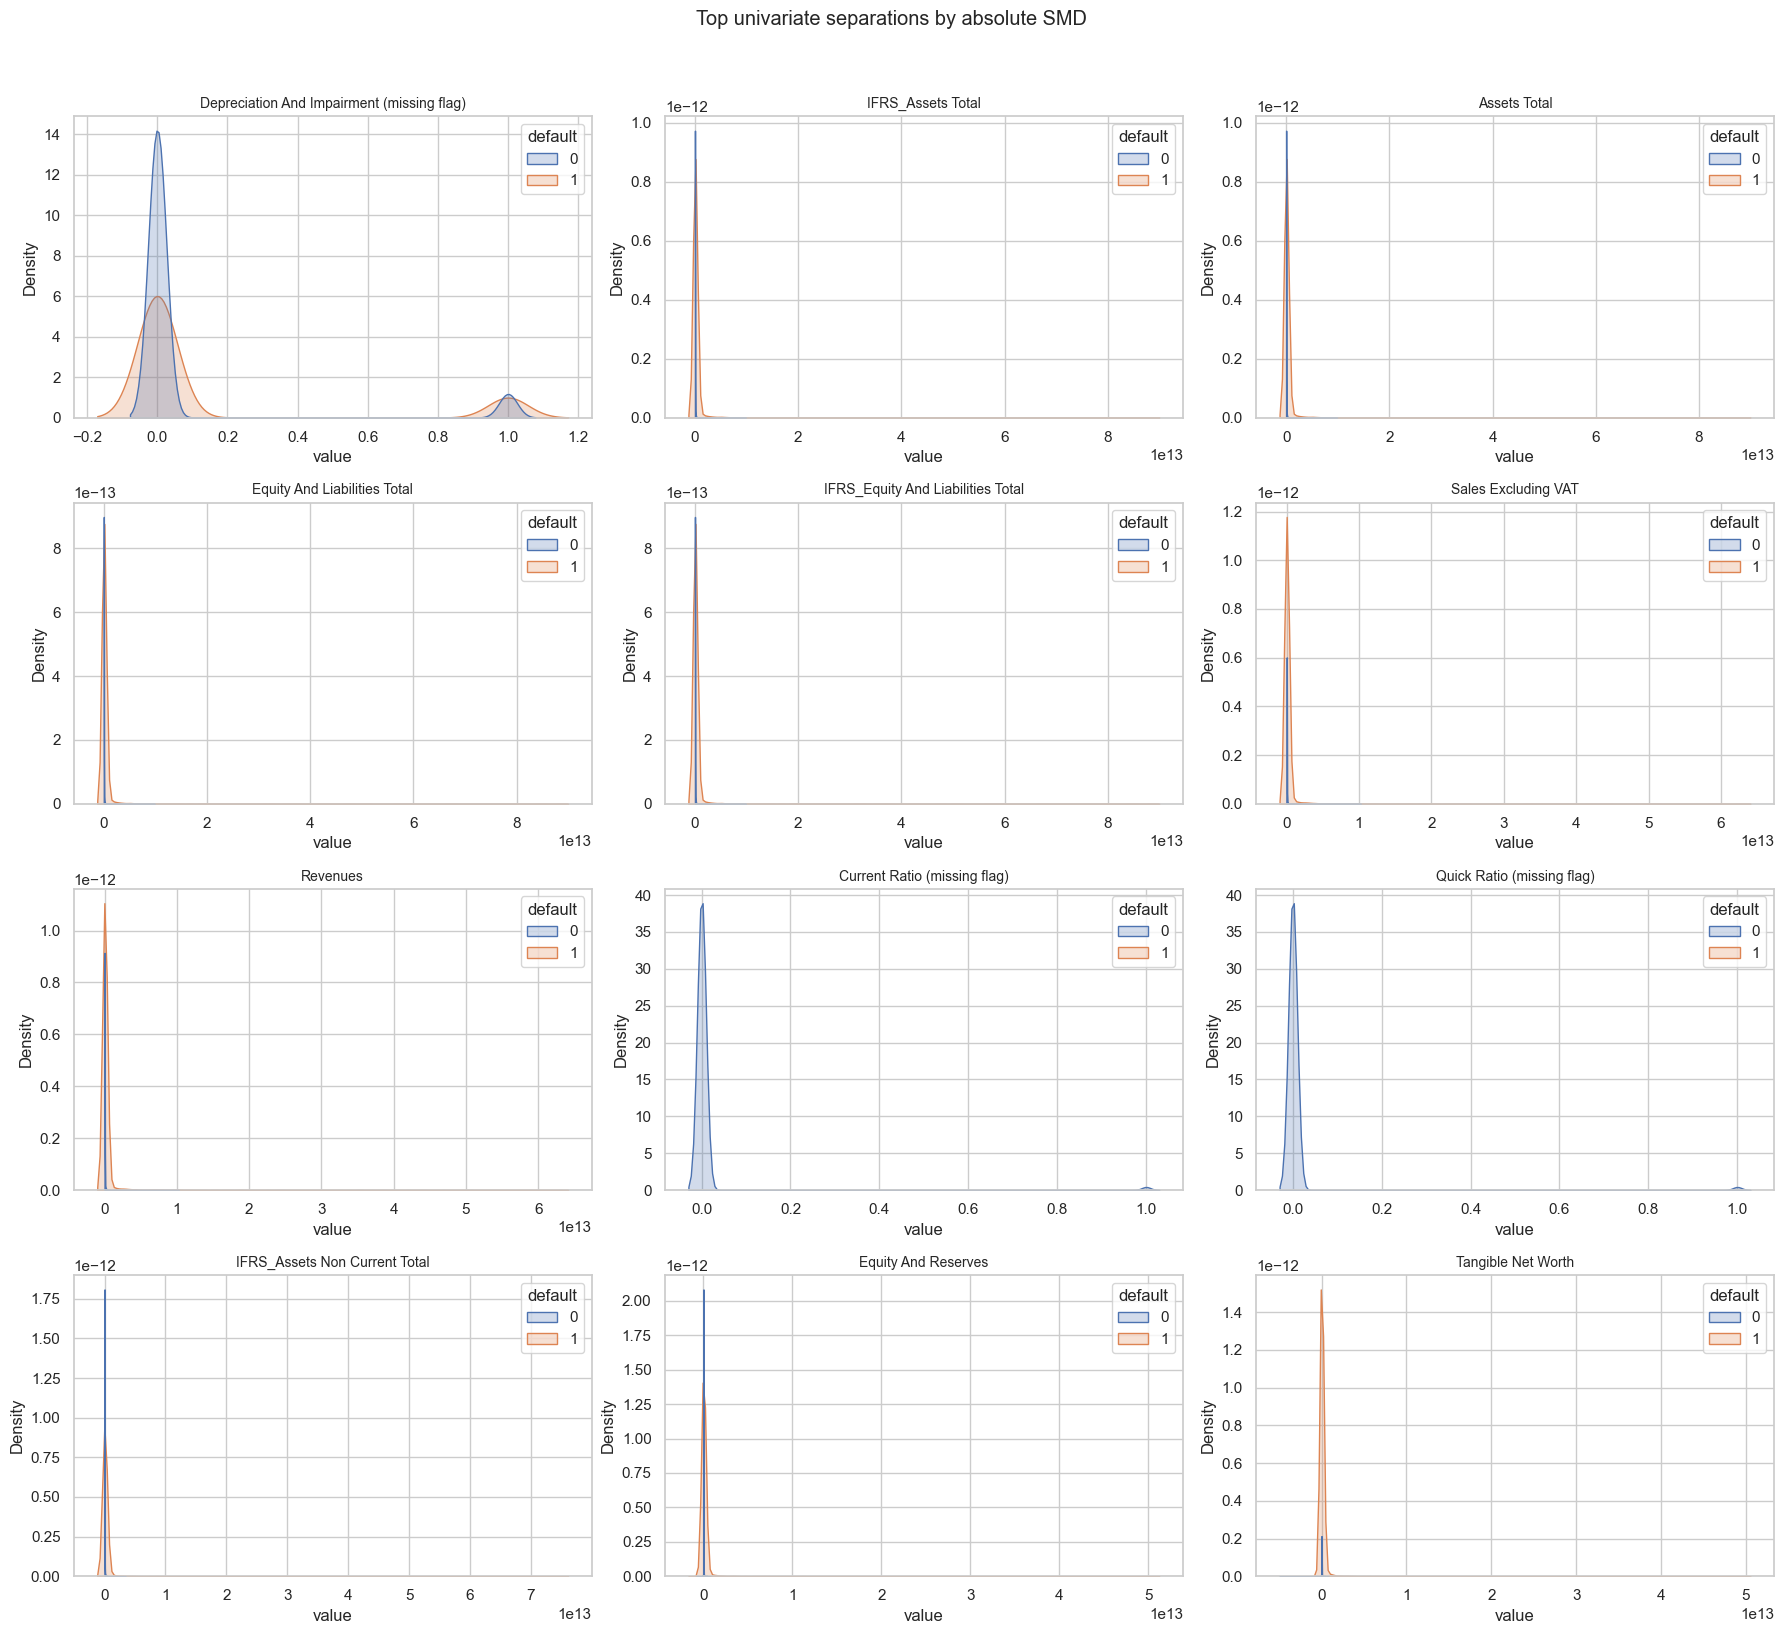

In [5]:
def compute_univariate_table(frame: pd.DataFrame, target: pd.Series, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        s0 = frame.loc[target == 0, col]
        s1 = frame.loc[target == 1, col]

        mu0 = s0.mean()
        mu1 = s1.mean()
        std0 = s0.std()
        std1 = s1.std()
        pooled_std = np.sqrt(((std0 ** 2) + (std1 ** 2)) / 2) if np.isfinite(std0) and np.isfinite(std1) else np.nan
        smd = (mu1 - mu0) / pooled_std if pooled_std and np.isfinite(pooled_std) and pooled_std != 0 else np.nan

        rows.append(
            {
                "feature": col,
                "feature_name": feature_display_name(col),
                "mean_non_default": mu0,
                "mean_default": mu1,
                "std_non_default": std0,
                "std_default": std1,
                "median_non_default": s0.median(),
                "median_default": s1.median(),
                "smd": smd,
                "abs_smd": abs(smd) if pd.notna(smd) else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


univariate_table = compute_univariate_table(X_train, y_train, feature_cols)
univariate_table.to_csv(OUTPUT_DIR / "feature_univariate_stats.csv", index=False)

display(univariate_table[[
    "feature",
    "feature_name",
    "mean_non_default",
    "mean_default",
    "smd",
    "abs_smd",
]].head(20))

plot_features = univariate_table["feature"].head(min(12, len(univariate_table))).tolist()

if plot_features:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, feature in zip(axes, plot_features):
        subset = pd.DataFrame({
            "value": X_train[feature],
            "default": y_train,
        })
        sns.kdeplot(
            data=subset,
            x="value",
            hue="default",
            common_norm=False,
            fill=True,
            alpha=0.25,
            ax=ax,
        )
        ax.set_title(feature_display_name(feature), fontsize=10)

    for ax in axes[len(plot_features):]:
        ax.axis("off")

    plt.suptitle("Top univariate separations by absolute SMD", y=1.02)
    plt.tight_layout()
    plt.show()


## 11. Correlation matrix and pairs with |r| > 0.7

High-correlation pairs (|r| > 0.7): 81


,feature_1,feature_1_name,feature_2,feature_2_name,correlation,abs_correlation
15,Var_01,Assets Current Total,Var_16,IFRS_Assets Current Total,1.000000,1.000000
92,Var_02,Assets Total,Var_18,IFRS_Assets Total,1.000000,1.000000
3054,Var_02_missing_flag,Assets Total (missing flag),Var_18_missing_flag,IFRS_Assets Total (missing flag),1.000000,1.000000
2977,Var_01_missing_flag,Assets Current Total (missing flag),Var_16_missing_flag,IFRS_Assets Current Total (missing flag),1.000000,1.000000
3210,Var_04_missing_flag,Current Ratio (missing flag),Var_25_missing_flag,Quick Ratio (missing flag),1.000000,1.000000
3655,Var_11_missing_flag,Equity And Liabilities Total (missing flag),Var_19_missing_flag,IFRS_Equity And Liabilities Total (missing flag),1.000000,1.000000
768,Var_11,Equity And Liabilities Total,Var_19,IFRS_Equity And Liabilities Total,1.000000,1.000000
3594,Var_10_missing_flag,Eff Tang Net Worth Actual (missing flag),Var_34_missing_flag,Tangible Net Worth (missing flag),1.000000,1.000000
85,Var_02,Assets Total,Var_11,Equity And Liabilities Total,0.999999,0.999999
767,Var_11,Equity And Liabilities Total,Var_18,IFRS_Assets Total,0.999999,0.999999


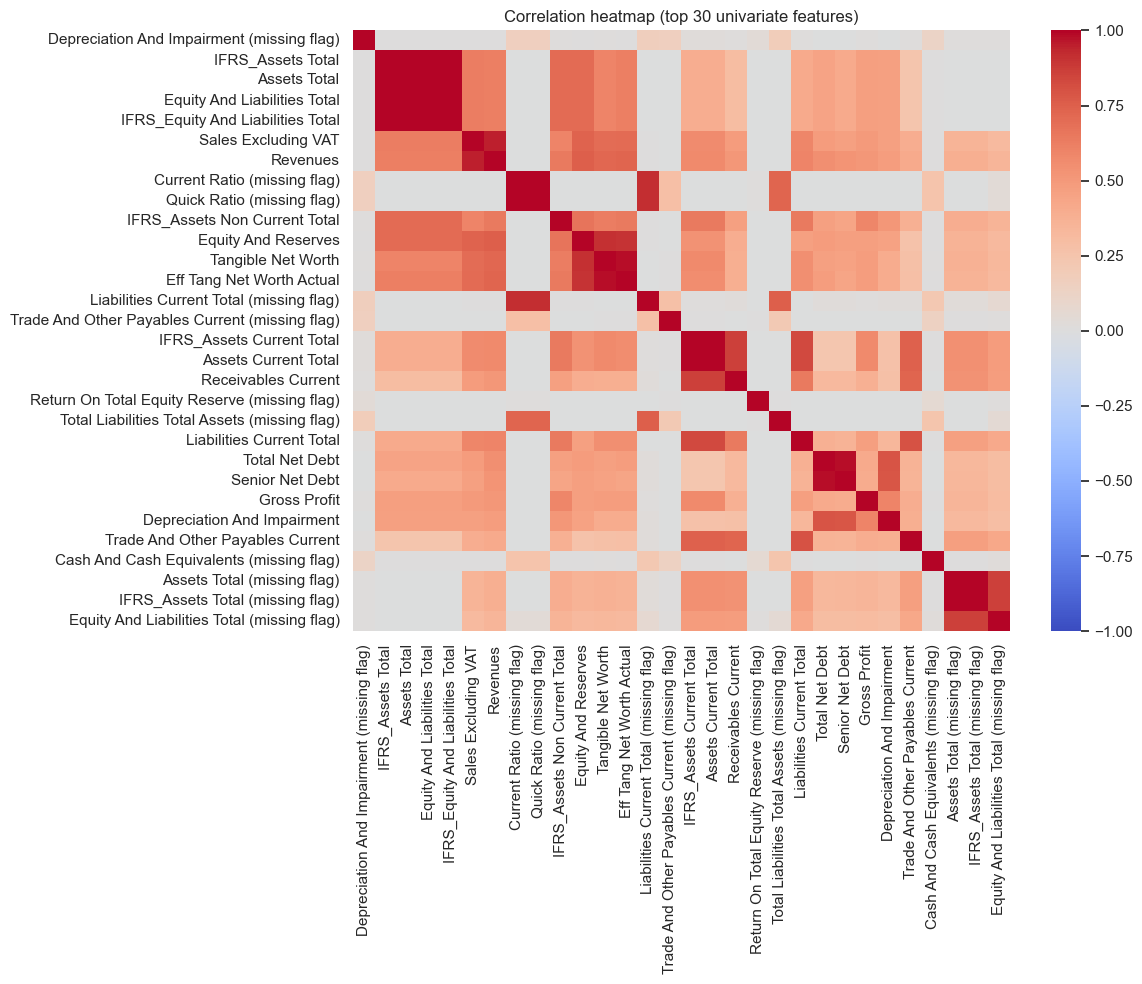

In [6]:
corr_matrix = X_train[feature_cols].corr(method="pearson")

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
high_corr_pairs["feature_1_name"] = high_corr_pairs["feature_1"].map(feature_display_name)
high_corr_pairs["feature_2_name"] = high_corr_pairs["feature_2"].map(feature_display_name)
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] > CORR_THRESHOLD]
high_corr_pairs = high_corr_pairs.sort_values("abs_correlation", ascending=False)

high_corr_pairs.to_csv(OUTPUT_DIR / "high_correlation_pairs.csv", index=False)

print(f"High-correlation pairs (|r| > {CORR_THRESHOLD}): {len(high_corr_pairs)}")
display(high_corr_pairs[[
    "feature_1",
    "feature_1_name",
    "feature_2",
    "feature_2_name",
    "correlation",
    "abs_correlation",
]].head(30))

# Heatmap for a readable subset.
plot_corr_features = univariate_table["feature"].head(min(30, len(univariate_table))).tolist()
if plot_corr_features:
    corr_plot = corr_matrix.loc[plot_corr_features, plot_corr_features].copy()
    corr_plot.index = [feature_display_name(c) for c in corr_plot.index]
    corr_plot.columns = [feature_display_name(c) for c in corr_plot.columns]

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_plot,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
    )
    plt.title("Correlation heatmap (top 30 univariate features)")
    plt.tight_layout()
    plt.show()


## 12. VIF filtering (drop features with VIF > threshold)

In [7]:
def compute_vif(frame: pd.DataFrame) -> pd.DataFrame:
    Xv = frame.astype(float)
    values = Xv.values
    rows = []
    for i, col in enumerate(Xv.columns):
        try:
            vif = variance_inflation_factor(values, i)
        except Exception:
            vif = np.inf
        rows.append({"feature": col, "vif": float(vif) if np.isfinite(vif) else np.inf})
    out = pd.DataFrame(rows).sort_values("vif", ascending=False)
    out["feature_name"] = out["feature"].map(feature_display_name)
    return out


vif_features = feature_cols.copy()
vif_drop_log = []
iteration = 0

while len(vif_features) > 1:
    iteration += 1
    current = X_train[vif_features]

    vif_table = compute_vif(current)
    top_feature = vif_table.iloc[0]["feature"]
    top_vif = float(vif_table.iloc[0]["vif"])

    if np.isfinite(top_vif) and top_vif <= VIF_THRESHOLD:
        break

    # Fallback for inf/ill-conditioned cases: drop feature with highest average abs correlation.
    if not np.isfinite(top_vif):
        corr_abs = current.corr().abs()
        corr_values = corr_abs.to_numpy(copy=True)
        np.fill_diagonal(corr_values, np.nan)
        corr_abs = pd.DataFrame(corr_values, index=corr_abs.index, columns=corr_abs.columns)
        top_feature = corr_abs.mean(skipna=True).sort_values(ascending=False).index[0]

    vif_drop_log.append(
        {
            "iteration": iteration,
            "dropped_feature": top_feature,
            "dropped_feature_name": feature_display_name(top_feature),
            "vif_before_drop": top_vif,
            "remaining_after_drop": len(vif_features) - 1,
        }
    )
    vif_features.remove(top_feature)

vif_final_table = compute_vif(X_train[vif_features])
vif_drop_log_df = pd.DataFrame(vif_drop_log)

vif_final_table.to_csv(OUTPUT_DIR / "vif_final_table.csv", index=False)
vif_drop_log_df.to_csv(OUTPUT_DIR / "vif_drop_log.csv", index=False)

print(f"Features before VIF filtering: {len(feature_cols)}")
print(f"Features after VIF filtering: {len(vif_features)}")
display(vif_final_table[["feature", "feature_name", "vif"]].head(20))
display(vif_drop_log_df.head(20))


Features before VIF filtering: 75
Features after VIF filtering: 47


,feature,feature_name,vif
14,Var_26,Receivables Current,8.557869
11,Var_21,Liabilities Current Total,7.120403
10,Var_20,Interest Expense,5.892077
22,Var_02_missing_flag,Assets Total (missing flag),5.840236
29,Var_12_missing_flag,Equity And Reserves (missing flag),5.692851
42,Var_31_missing_flag,Sales Total Assets (missing flag),4.989419
27,Var_10_missing_flag,Eff Tang Net Worth Actual (missing flag),4.952410
28,Var_11_missing_flag,Equity And Liabilities Total (missing flag),4.808603
46,Var_39_missing_flag,Working Capital (missing flag),4.687571
4,Var_06,Depreciation And Impairment,4.501099


,iteration,dropped_feature,dropped_feature_name,vif_before_drop,remaining_after_drop
0,1,Var_32,Senior Net Debt,3.816610e+13,74
1,2,Var_18,IFRS_Assets Total,2.370316e+14,73
2,3,Var_11,Equity And Liabilities Total,3.602880e+13,72
3,4,Var_01,Assets Current Total,inf,71
4,5,Var_25_missing_flag,Quick Ratio (missing flag),2.075589e+06,70
5,6,Var_19,IFRS_Equity And Liabilities Total,6.040863e+05,69
6,7,Var_01_missing_flag,Assets Current Total (missing flag),1.543234e+06,68
7,8,Var_25,Quick Ratio,4.561145e+05,67
8,9,Var_36_missing_flag,Total Net Debt (missing flag),4.358321e+03,66
9,10,Var_34_missing_flag,Tangible Net Worth (missing flag),3.100726e+03,65


## 13-15. Optimal binning, WoE transformation, IV ranking

In [8]:
def fit_optbinning_woe(
    X_fit: pd.DataFrame,
    y_fit: pd.Series,
    features: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, OptimalBinning], list[dict[str, str]]]:
    woe_df = pd.DataFrame(index=X_fit.index)
    iv_rows = []
    models: dict[str, OptimalBinning] = {}
    failed: list[dict[str, str]] = []

    for feature in features:
        x = X_fit[feature].values

        try:
            optb = OptimalBinning(
                name=feature,
                dtype="numerical",
                solver="cp",
                max_n_prebins=20,
                min_prebin_size=0.05,
            )
            optb.fit(x, y_fit.values)

            # WoE transformation
            woe_df[feature] = optb.transform(x, metric="woe")

            # Build binning table and extract IV/quality.
            _ = optb.binning_table.build()
            iv_value = float(optb.binning_table.iv)
            quality_score = getattr(optb.binning_table, "quality_score", np.nan)
            quality_score = float(quality_score) if pd.notna(quality_score) else np.nan

            splits = optb.splits if optb.splits is not None else []
            n_bins = int(len(splits) + 1) if len(splits) > 0 else int(np.unique(x).size)

            iv_rows.append(
                {
                    "feature": feature,
                    "feature_name": feature_display_name(feature),
                    "iv": iv_value,
                    "quality_score": quality_score,
                    "status": str(optb.status),
                    "n_bins": n_bins,
                }
            )
            models[feature] = optb

        except Exception as exc:
            failed.append({"feature": feature, "feature_name": feature_display_name(feature), "error": str(exc)})

    if iv_rows:
        iv_df = pd.DataFrame(iv_rows).sort_values("iv", ascending=False)
    else:
        iv_df = pd.DataFrame(columns=["feature", "feature_name", "iv", "quality_score", "status", "n_bins"])
    return woe_df, iv_df, models, failed


X_train_vif = X_train[vif_features].copy()
X_test_vif = X_test[vif_features].copy()

woe_train, iv_summary, optb_models, failed_optb = fit_optbinning_woe(X_train_vif, y_train, vif_features)

failed_optb_df = pd.DataFrame(failed_optb)
if not failed_optb_df.empty:
    failed_optb_df.to_csv(OUTPUT_DIR / "optbinning_failed_features.csv", index=False)

# Apply trained optbinning models to test and full modeling data.
woe_test = pd.DataFrame(index=X_test_vif.index)
woe_full = pd.DataFrame(index=X.index)
for feature, model in optb_models.items():
    woe_test[feature] = model.transform(X_test_vif[feature].values, metric="woe")
    woe_full[feature] = model.transform(X[feature].values, metric="woe")

iv_summary.to_csv(OUTPUT_DIR / "woe_iv_summary.csv", index=False)
woe_train.to_csv(OUTPUT_DIR / "woe_train_features.csv", index=False)
woe_test.to_csv(OUTPUT_DIR / "woe_test_features.csv", index=False)

print(f"Features entered binning: {len(vif_features)}")
print(f"Features binned successfully: {len(optb_models)}")
print(f"Features failed during binning: {len(failed_optb)}")

display(iv_summary[["feature", "feature_name", "iv", "status", "n_bins"]].head(25))
display(failed_optb_df.head(20))


Features entered binning: 47
Features binned successfully: 46
Features failed during binning: 1


,feature,feature_name,iv,status,n_bins
0,Var_02,Assets Total,4.766784,OPTIMAL,6
20,Var_39,Working Capital,4.337604,OPTIMAL,12
5,Var_10,Eff Tang Net Worth Actual,4.197577,OPTIMAL,14
11,Var_22,Net Profit,3.393618,OPTIMAL,13
8,Var_17,IFRS_Assets Non Current Total,2.927322,OPTIMAL,9
19,Var_36,Total Net Debt,2.790465,OPTIMAL,14
10,Var_21,Liabilities Current Total,2.731389,OPTIMAL,13
13,Var_26,Receivables Current,2.503090,OPTIMAL,12
16,Var_29,Revenues,2.411909,OPTIMAL,13
1,Var_03,Cash And Cash Equivalents,2.354365,OPTIMAL,9


,feature,feature_name,error
0,Var_05,Debt Net Worth,__radd__(): incompatible function arguments. T...


In [9]:
# IV filtering
iv_selected_df = iv_summary[iv_summary["iv"] >= IV_MIN].copy()
iv_selected_features = iv_selected_df["feature"].tolist()

print(f"IV threshold: {IV_MIN}")
print(f"Features with IV >= threshold: {len(iv_selected_features)}")

iv_selected_df.to_csv(OUTPUT_DIR / "iv_selected_features.csv", index=False)
display(iv_selected_df[["feature", "feature_name", "iv", "status", "n_bins"]].head(30))


IV threshold: 0.02
Features with IV >= threshold: 21


,feature,feature_name,iv,status,n_bins
0,Var_02,Assets Total,4.766784,OPTIMAL,6
20,Var_39,Working Capital,4.337604,OPTIMAL,12
5,Var_10,Eff Tang Net Worth Actual,4.197577,OPTIMAL,14
11,Var_22,Net Profit,3.393618,OPTIMAL,13
8,Var_17,IFRS_Assets Non Current Total,2.927322,OPTIMAL,9
19,Var_36,Total Net Debt,2.790465,OPTIMAL,14
10,Var_21,Liabilities Current Total,2.731389,OPTIMAL,13
13,Var_26,Receivables Current,2.503090,OPTIMAL,12
16,Var_29,Revenues,2.411909,OPTIMAL,13
1,Var_03,Cash And Cash Equivalents,2.354365,OPTIMAL,9


## 16. Final 8-15 features (high IV, low mutual correlation)

Selected features count: 9
Selected features (technical): ['Var_02', 'Var_28', 'Var_04', 'Var_15', 'Var_35', 'Var_23', 'Var_33', 'Var_06_missing_flag', 'Var_07']
Selected features (readable): ['Assets Total', 'Return On Total Equity Reserve', 'Current Ratio', 'Gross Profit Margin', 'Total Liabilities Total Assets', 'Net Profit Margin', 'Senior Net Debt EBITDA', 'Depreciation And Impairment (missing flag)', 'EBITDA Margin']
Saved: data\logit_selected_woe_dataset.csv
Saved: data\logit_selected_woe_dataset_readable.csv
Saved: data\selected_features_for_logit.csv
Saved: data\selected_features_for_logit.json


,feature,feature_name,iv,status,n_bins
0,Var_02,Assets Total,4.766784,OPTIMAL,6
15,Var_28,Return On Total Equity Reserve,0.268057,OPTIMAL,10
2,Var_04,Current Ratio,0.116250,OPTIMAL,10
7,Var_15,Gross Profit Margin,0.108938,OPTIMAL,11
18,Var_35,Total Liabilities Total Assets,0.064572,OPTIMAL,8
12,Var_23,Net Profit Margin,0.064106,OPTIMAL,8
17,Var_33,Senior Net Debt EBITDA,0.059829,OPTIMAL,11
23,Var_06_missing_flag,Depreciation And Impairment (missing flag),0.045203,OPTIMAL,2
4,Var_07,EBITDA Margin,0.041568,OPTIMAL,11


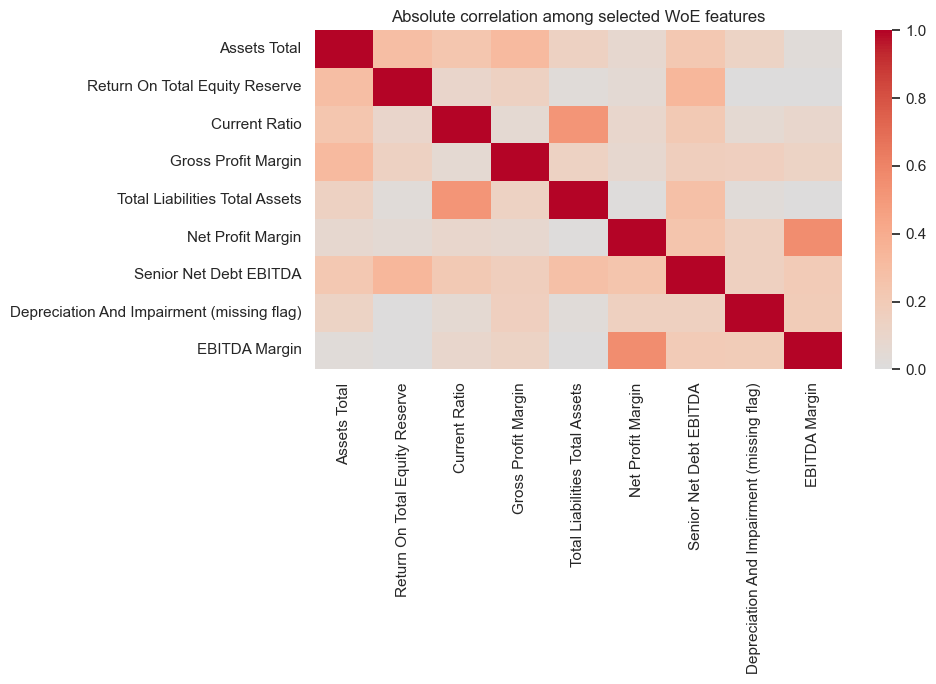

In [10]:
# Correlation on WoE-transformed train features improves compatibility with final logistic input.
woe_corr = woe_train.corr().abs()

ordered_by_iv = iv_selected_df.sort_values("iv", ascending=False)["feature"].tolist()

selected_features = []
for feature in ordered_by_iv:
    if len(selected_features) >= FINAL_FEATURES_MAX:
        break

    if not selected_features:
        selected_features.append(feature)
        continue

    max_corr = max(abs(woe_corr.loc[feature, s]) for s in selected_features)
    if max_corr < CORR_THRESHOLD:
        selected_features.append(feature)

# If strict filtering selected too few features, relax only to reach minimum.
if len(selected_features) < FINAL_FEATURES_MIN:
    for feature in ordered_by_iv:
        if feature in selected_features:
            continue
        selected_features.append(feature)
        if len(selected_features) >= FINAL_FEATURES_MIN:
            break

selected_features = selected_features[:FINAL_FEATURES_MAX]
selected_features_readable = [feature_display_name(f) for f in selected_features]

selected_table = iv_summary[iv_summary["feature"].isin(selected_features)].copy()
selected_table = selected_table.sort_values("iv", ascending=False)

# Prepare logistic-ready WoE dataset and keep split labels for leakage-safe downstream modeling.
id_date_target = [c for c in [ID_COL, DATE_COL, TARGET_COL] if c in model_df.columns]

logit_dataset = pd.concat(
    [
        model_df[id_date_target].reset_index(drop=True),
        model_df["split"].rename("data_split").reset_index(drop=True),
        woe_full[selected_features].reset_index(drop=True),
    ],
    axis=1,
)

logit_dataset_readable = logit_dataset.rename(columns={f: feature_display_name(f) for f in selected_features})

logit_dataset_path = OUTPUT_DIR / "logit_selected_woe_dataset.csv"
logit_dataset_readable_path = OUTPUT_DIR / "logit_selected_woe_dataset_readable.csv"
selected_features_json_path = OUTPUT_DIR / "selected_features_for_logit.json"
selected_features_csv_path = OUTPUT_DIR / "selected_features_for_logit.csv"

logit_dataset.to_csv(logit_dataset_path, sep=";", index=False)
logit_dataset_readable.to_csv(logit_dataset_readable_path, sep=";", index=False)
selected_table.to_csv(selected_features_csv_path, index=False)
selected_features_json_path.write_text(
    json.dumps(
        {
            "selected_features": selected_features,
            "selected_features_readable": selected_features_readable,
            "settings": {
                "corr_threshold": CORR_THRESHOLD,
                "vif_threshold": VIF_THRESHOLD,
                "iv_min": IV_MIN,
                "final_features_min": FINAL_FEATURES_MIN,
                "final_features_max": FINAL_FEATURES_MAX,
                "modeling_split_strategy": MODELING_SPLIT_STRATEGY,
            },
        },
        indent=2,
    ),
    encoding="utf-8",
)

print(f"Selected features count: {len(selected_features)}")
print(f"Selected features (technical): {selected_features}")
print(f"Selected features (readable): {selected_features_readable}")
print(f"Saved: {logit_dataset_path}")
print(f"Saved: {logit_dataset_readable_path}")
print(f"Saved: {selected_features_csv_path}")
print(f"Saved: {selected_features_json_path}")

display(selected_table[["feature", "feature_name", "iv", "status", "n_bins"]])

if selected_features:
    plot_corr = woe_corr.loc[selected_features, selected_features].copy()
    plot_corr.index = [feature_display_name(c) for c in plot_corr.index]
    plot_corr.columns = [feature_display_name(c) for c in plot_corr.columns]

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        plot_corr,
        cmap="coolwarm",
        center=0,
        vmin=0,
        vmax=1,
        annot=False,
    )
    plt.title("Absolute correlation among selected WoE features")
    plt.tight_layout()
    plt.show()


## Outputs

This notebook writes the following files in `data/`:
- `data_split_out_of_sample_train_test.csv`
- `data_split_out_of_time_last_year_train_test.csv`
- `company_best_case_once.csv`
- `data_split_summary.csv`
- `feature_univariate_stats.csv`
- `high_correlation_pairs.csv`
- `vif_final_table.csv`
- `vif_drop_log.csv`
- `woe_iv_summary.csv`
- `woe_train_features.csv`
- `woe_test_features.csv`
- `iv_selected_features.csv`
- `selected_features_for_logit.csv`
- `selected_features_for_logit.json`
- `logit_selected_woe_dataset.csv`
- `logit_selected_woe_dataset_readable.csv`
- `optbinning_failed_features.csv` (only if failures occur)
